# Marketing-lift scenario notebook (Mobile DAU, 2026)

Drop in a weekly paid-DAU forecast CSV from the marketing team and see the resulting 2026 mobile DAU curve overlaid on the production baseline, the April N-1 reference, and the December 15 stakeholder targets. Headwinds are applied automatically.

**What you need to do:**
1. Put your CSV in this folder (or anywhere — you'll set the path below).
2. Edit the `[user-config]` cell to point at your CSV and confirm the column names.
3. Hit **Run All**.

**Expected CSV shape:** one row per Monday (the function checks this), one column with the date, one column with the weekly total paid DAU level (snapshot, not weekly sum). Comma-thousands (e.g. `1,019,515`) is fine. See `example_csv.csv` for a working template.

**About the plot:** four lines + three gold target markers. The green line is *your* scenario. The orange dashed line is what we'd get with zero marketing lift; the gap between green and orange is your scenario's implied marketing benefit.

For methodology and caveats, see `README.md` in this folder.


In [1]:
# [user-config]
# Edit the four values below, then Run All.
# Everything else in the notebook is wired up — no other cells should need editing.

CSV_PATH = "example_csv.csv"          # path to your weekly paid-DAU CSV (relative to this notebook)
CSV_DATE_COLUMN = "week"              # the column with the Monday date
CSV_LIFT_COLUMN = "total_paid_dau"    # the column with total weekly paid DAU
SCENARIO_LABEL = "My scenario"        # appears in the plot legend and title


In [2]:
# [setup]
# Stdlib + pandas + numpy + matplotlib only. No imports outside this cell.

import json
from datetime import date
from pathlib import Path

import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import pandas as pd

# Resolve bundle paths from the notebook's directory.
# `Path.cwd()` is reliable when the notebook is launched from its own folder
# (which the README instructs); the `Path(__file__).parent` fallback used in
# Python scripts is not available inside Jupyter, so just rely on cwd.
BUNDLE_DIR = Path.cwd()
DATA_DIR = BUNDLE_DIR / "data"
assert (DATA_DIR / "no_mktg_baseline_world_daily.parquet").exists(), (
    f"Bundle data not found at {DATA_DIR}. "
    "Launch Jupyter from inside the stakeholder_scenarios folder."
)

# Constants pinned to this snapshot. If you regenerate the bundle, these stay valid
# unless the production training_end or measurement date changes.
CAMPAIGN_LAUNCH = pd.Timestamp("2026-04-06")
TRAINING_END = pd.Timestamp("2026-05-16")          # last day of historical Fenix gap
FORECAST_START = pd.Timestamp("2026-05-17")        # first day of the new forecast
PREV_FORECAST_START = pd.Timestamp("2026-04-01")   # April N-1 forecast's start
MEASUREMENT_DATE = pd.Timestamp("2026-12-15")
PARQUET_END = pd.Timestamp("2026-12-31")
DISPLAY_START = pd.Timestamp("2026-01-01")
DISPLAY_END = pd.Timestamp("2026-12-31")
MA_WINDOW = 28


def millions(x, pos):
    return f"{x / 1e6:.1f}M"


In [3]:
# [load-csv]
# Read the stakeholder CSV. Handles comma-thousands. Validates Monday dates.

csv_path = BUNDLE_DIR / CSV_PATH if not Path(CSV_PATH).is_absolute() else Path(CSV_PATH)
assert csv_path.exists(), f"CSV not found at {csv_path}"

weekly_raw = pd.read_csv(csv_path, thousands=",")
assert CSV_DATE_COLUMN in weekly_raw.columns, (
    f"Date column {CSV_DATE_COLUMN!r} not found. Available columns: {list(weekly_raw.columns)}"
)
assert CSV_LIFT_COLUMN in weekly_raw.columns, (
    f"Lift column {CSV_LIFT_COLUMN!r} not found. Available columns: {list(weekly_raw.columns)}"
)

weekly = pd.DataFrame({
    "week_starting": pd.to_datetime(weekly_raw[CSV_DATE_COLUMN]),
    "total_paid_dau": pd.to_numeric(weekly_raw[CSV_LIFT_COLUMN], errors="raise"),
}).sort_values("week_starting").reset_index(drop=True)

dow = weekly["week_starting"].dt.dayofweek
assert (dow == 0).all(), (
    f"All dates must be Mondays. Non-Monday rows: "
    f"{weekly.loc[dow != 0, 'week_starting'].dt.date.tolist()}"
)

print(f"Loaded {len(weekly)} weekly rows from {csv_path.name}")
print(f"Date range: {weekly['week_starting'].min().date()} → {weekly['week_starting'].max().date()}")
print(f"First row:  {weekly.iloc[0]['week_starting'].date()}  {weekly.iloc[0]['total_paid_dau']:>12,.0f}")
print(f"Last row:   {weekly.iloc[-1]['week_starting'].date()}  {weekly.iloc[-1]['total_paid_dau']:>12,.0f}")


Loaded 52 weekly rows from example_csv.csv
Date range: 2026-01-05 → 2026-12-28
First row:  2026-01-05       844,764
Last row:   2026-12-28     1,374,596


In [4]:
# [interpolate-daily]
# Linear-interpolate weekly Monday anchors to daily values. Forward-fill any
# trailing days past the last Monday so coverage extends to PARQUET_END.

weekly_indexed = weekly.set_index("week_starting")["total_paid_dau"].astype("float64")

interp_index = pd.date_range(weekly_indexed.index.min(), weekly_indexed.index.max(), freq="D")
csv_daily = weekly_indexed.reindex(interp_index).interpolate(method="linear", limit_area="inside")

# Extend to PARQUET_END by forward-filling the last value (the marketing CSV
# typically ends at the last Monday of December, leaving a few days unfilled).
full_index = pd.date_range(weekly_indexed.index.min(), PARQUET_END, freq="D")
csv_daily = csv_daily.reindex(full_index).ffill()

assert csv_daily.isna().sum() == 0, "interpolation produced NaNs"

print(f"Daily paid DAU series: {csv_daily.index.min().date()} → {csv_daily.index.max().date()}  "
      f"({len(csv_daily)} days)")
print(f"Value at TRAINING_END ({TRAINING_END.date()}):  {csv_daily.loc[TRAINING_END]:>12,.0f}")
print(f"Value at MEASUREMENT_DATE ({MEASUREMENT_DATE.date()}):  {csv_daily.loc[MEASUREMENT_DATE]:>12,.0f}")


Daily paid DAU series: 2026-01-05 → 2026-12-31  (361 days)
Value at TRAINING_END (2026-05-16):     1,315,453
Value at MEASUREMENT_DATE (2026-12-15):     1,365,112


In [5]:
# [load-bundled-data]
# Load the four pre-computed parquets + two JSONs that ship with this notebook.

def _read_series(path, value_column):
    df = pd.read_parquet(path)
    df["date"] = pd.to_datetime(df["date"])
    return df.set_index("date").sort_index()[value_column]


no_mktg_baseline = _read_series(DATA_DIR / "no_mktg_baseline_world_daily.parquet", "dau")
april_n1 = _read_series(DATA_DIR / "april_n1_world_daily.parquet", "dau")
fenix_gap_daily = _read_series(DATA_DIR / "fenix_gap_daily.parquet", "fenix_gap_daily")
mobile_actuals = _read_series(DATA_DIR / "mobile_actuals_daily.parquet", "dau")

headwind_spec = json.loads((DATA_DIR / "headwind_spec.json").read_text())
stakeholder_targets = json.loads((DATA_DIR / "stakeholder_targets.json").read_text())
snapshot_manifest = json.loads((DATA_DIR / "snapshot_manifest.json").read_text())

print(f"Bundle snapshot date: {snapshot_manifest['snapshot_date_utc']}  "
      f"(forecast cycle {snapshot_manifest['forecast_cycle']}, training_end {snapshot_manifest['training_end']})")
print(f"  no-mktg baseline:  {len(no_mktg_baseline):>5} rows  "
      f"({no_mktg_baseline.index.min().date()} → {no_mktg_baseline.index.max().date()})")
print(f"  April N-1:         {len(april_n1):>5} rows  "
      f"({april_n1.index.min().date()} → {april_n1.index.max().date()})")
print(f"  Fenix gap (hist):  {len(fenix_gap_daily):>5} rows  "
      f"({fenix_gap_daily.index.min().date()} → {fenix_gap_daily.index.max().date()})")
print(f"  Mobile actuals:    {len(mobile_actuals):>5} rows  "
      f"({mobile_actuals.index.min().date()} → {mobile_actuals.index.max().date()})")
print(f"  Headwind: {headwind_spec['type']}  "
      f"{headwind_spec['start_date']} → {headwind_spec['anchor_date']}  "
      f"target mobile_dau = {headwind_spec.get('mobile_dau'):+,}")
print(f"  Stakeholder targets ({stakeholder_targets['measurement_date']}): "
      f"Stretch {stakeholder_targets['stretch']:,}, "
      f"Base {stakeholder_targets['base']:,}, "
      f"Low {stakeholder_targets['low']:,}")


Bundle snapshot date: 2026-05-20  (forecast cycle 2026-06, training_end 2026-05-16)
  no-mktg baseline:   2557 rows  (2020-12-31 → 2027-12-31)
  April N-1:          2557 rows  (2020-12-31 → 2027-12-31)
  Fenix gap (hist):   1962 rows  (2021-01-01 → 2026-05-16)
  Mobile actuals:      166 rows  (2025-12-04 → 2026-05-18)
  Headwind: linear_ramp  2026-04-01 → 2026-12-15  target mobile_dau = -27,162
  Stakeholder targets (2026-12-15): Stretch 17,742,615, Base 17,522,795, Low 17,019,424


In [6]:
# [build-hybrid-lift]
# Construct the daily marketing-lift series with the same hybrid recipe used
# in the internal `04_v2_hybrid_lift.ipynb`:
#
#   d <  CAMPAIGN_LAUNCH         → lift = 0
#   CAMPAIGN_LAUNCH ≤ d ≤ training_end → lift = empirical Fenix gap on that day
#   d >  training_end            → lift = gap_at_training_end + (csv_daily(d) − csv_daily(training_end))
#
# The historical portion is fixed by reality; only the forward growth comes
# from the stakeholder's CSV.

PARQUET_START = pd.Timestamp("2026-02-01")
full_index = pd.date_range(PARQUET_START, PARQUET_END, freq="D")

gap_at_training_end = float(fenix_gap_daily.loc[TRAINING_END])
csv_at_training_end = float(csv_daily.loc[TRAINING_END])

# Future portion: anchored CSV growth
future_lift = (csv_daily - csv_at_training_end) + gap_at_training_end

hybrid_lift = pd.Series(0.0, index=full_index, name="marketing_lift_daily")
hist_mask = (full_index >= CAMPAIGN_LAUNCH) & (full_index <= TRAINING_END)
hybrid_lift.loc[full_index[hist_mask]] = fenix_gap_daily.reindex(full_index[hist_mask]).values
future_mask = full_index > TRAINING_END
hybrid_lift.loc[full_index[future_mask]] = future_lift.reindex(full_index[future_mask]).values

assert hybrid_lift.isna().sum() == 0
assert (hybrid_lift.loc[: CAMPAIGN_LAUNCH - pd.Timedelta(days=1)] == 0.0).all()

print(f"Stitch parameters:")
print(f"  TRAINING_END:                       {TRAINING_END.date()}")
print(f"  Empirical gap at training_end:      {gap_at_training_end:>+12,.0f}")
print(f"  Your CSV at training_end:           {csv_at_training_end:>12,.0f}")
print(f"  Your CSV at year-end:               {csv_daily.loc[PARQUET_END]:>12,.0f}")
print(f"  Forward CSV delta (year-end−train_end): {csv_daily.loc[PARQUET_END] - csv_at_training_end:>+12,.0f}")
print()
print("Hybrid lift snapshot:")
print(f"  {'date':>10}  {'lift_daily':>14}")
for d in [pd.Timestamp("2026-03-01"), CAMPAIGN_LAUNCH, TRAINING_END,
          FORECAST_START, pd.Timestamp("2026-07-01"), pd.Timestamp("2026-09-01"),
          MEASUREMENT_DATE, PARQUET_END]:
    print(f"  {d.date()}  {hybrid_lift.loc[d]:>+14,.0f}")


Stitch parameters:
  TRAINING_END:                       2026-05-16
  Empirical gap at training_end:          +494,378
  Your CSV at training_end:              1,315,453
  Your CSV at year-end:                  1,374,596
  Forward CSV delta (year-end−train_end):      +59,143

Hybrid lift snapshot:
        date      lift_daily
  2026-03-01              +0
  2026-04-06          -3,985
  2026-05-16        +494,378
  2026-05-17        +498,972
  2026-07-01        +597,987
  2026-09-01        +551,170
  2026-12-15        +544,037
  2026-12-31        +553,521


In [7]:
# [apply-lift-to-baseline]
# scenario(d) = no_mktg_baseline(d) + hybrid_lift(d)
# Align both series on the daily index and add. The baseline carries the
# Prophet-fit forecast level; the hybrid lift adds the marketing contribution.

baseline_index = no_mktg_baseline.index
hybrid_aligned = hybrid_lift.reindex(baseline_index, fill_value=0.0)
scenario_daily = no_mktg_baseline + hybrid_aligned
scenario_daily.name = "scenario_dau"

print(f"Scenario daily DAU: {len(scenario_daily)} rows, "
      f"{scenario_daily.index.min().date()} → {scenario_daily.index.max().date()}")
print(f"Sample at MEASUREMENT_DATE ({MEASUREMENT_DATE.date()}):")
print(f"  no-mktg baseline:  {no_mktg_baseline.loc[MEASUREMENT_DATE]:>+15,.0f}")
print(f"  hybrid lift:       {hybrid_aligned.loc[MEASUREMENT_DATE]:>+15,.0f}")
print(f"  scenario total:    {scenario_daily.loc[MEASUREMENT_DATE]:>+15,.0f}")


Scenario daily DAU: 2557 rows, 2020-12-31 → 2027-12-31
Sample at MEASUREMENT_DATE (2026-12-15):
  no-mktg baseline:      +16,524,133
  hybrid lift:              +544,037
  scenario total:        +17,068,169


In [8]:
# [compute-ma-and-headwinds]
# 28-day moving average for each series, then apply the linear-ramp headwind
# to the forecast lines. April N-1's headwind is anchored at April's forecast
# start (the N-1 comparison convention); the others at this cycle's forecast start.


def to_ma28(series):
    return series.sort_index().rolling(MA_WINDOW).mean()


def render_headwind(spec, date_index):
    """Re-implementation of the production linear-ramp renderer for mobile only."""
    idx = pd.DatetimeIndex(date_index)
    if spec["type"] != "linear_ramp":
        raise ValueError(f"This notebook only handles linear_ramp headwinds; got {spec['type']!r}")
    start = pd.Timestamp(spec["start_date"])
    anchor = pd.Timestamp(spec["anchor_date"])
    total_days = (anchor - start).days
    elapsed = np.maximum(0, (idx - start).days)
    return pd.Series(spec.get("mobile_dau", 0) * elapsed / total_days, index=idx)


def apply_headwind(ma_series, headwind, forecast_start):
    """Additively apply the headwind to MA values on or after `forecast_start`."""
    result = ma_series.copy()
    headwind = headwind.reindex(result.index, fill_value=0.0)
    mask = result.index >= forecast_start
    result.loc[mask] = result.loc[mask] + headwind.loc[mask]
    return result


scenario_ma = to_ma28(scenario_daily)
baseline_ma = to_ma28(no_mktg_baseline)
april_ma = to_ma28(april_n1)
actuals_ma = to_ma28(mobile_actuals)

# Build the headwind on the union of all the MA indices we need.
headwind_index = scenario_ma.index.union(april_ma.index)
headwind = render_headwind(headwind_spec, headwind_index)

scenario_ma_h = apply_headwind(scenario_ma, headwind, FORECAST_START)
baseline_ma_h = apply_headwind(baseline_ma, headwind, FORECAST_START)
april_ma_h = apply_headwind(april_ma, headwind, PREV_FORECAST_START)

print(f"Headwind net adjustment at {MEASUREMENT_DATE.date()}: "
      f"{headwind.loc[MEASUREMENT_DATE]:+,.0f} DAU")
print(f"All MA series ready.")


Headwind net adjustment at 2026-12-15: -27,162 DAU
All MA series ready.


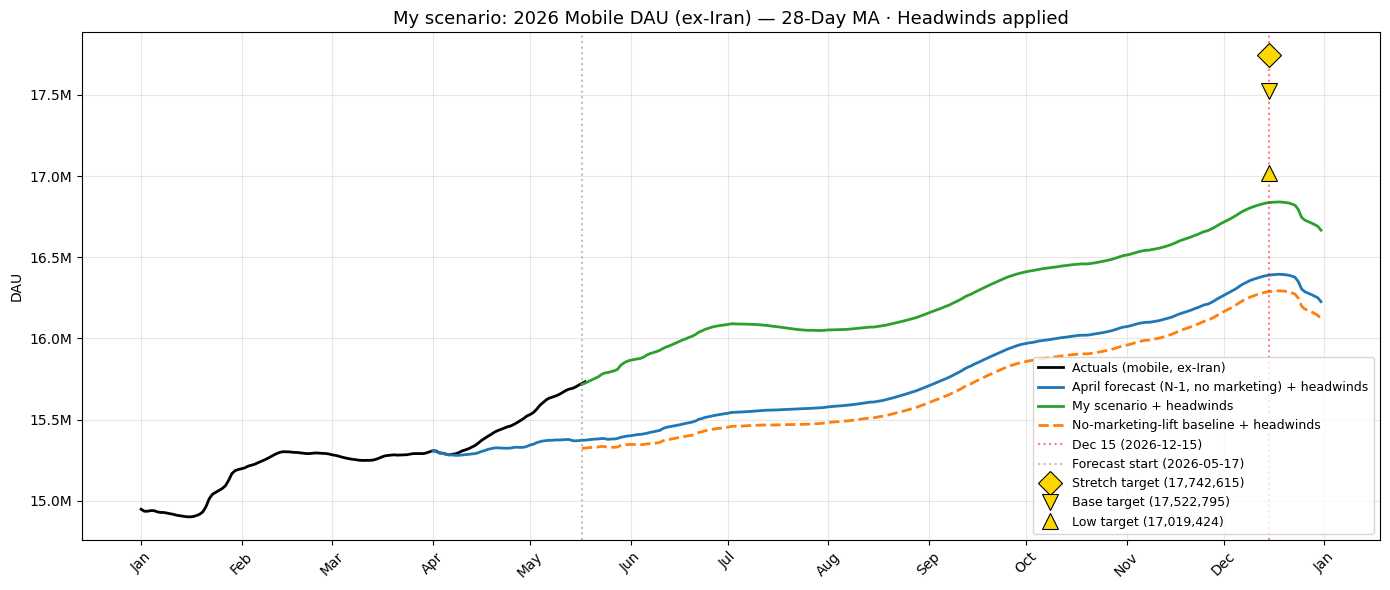

In [9]:
# [plot]
# Same visual style as the internal 05 diagnostic: actuals + April N-1 +
# stakeholder scenario + no-marketing baseline, with Dec-15 target markers.


def clip_display(s):
    return s[(s.index >= DISPLAY_START) & (s.index <= DISPLAY_END)]


def clip_forecast(s):
    return s[(s.index >= FORECAST_START) & (s.index <= DISPLAY_END)]


fig, ax = plt.subplots(figsize=(14, 6))

ax.plot(clip_display(actuals_ma),
        label="Actuals (mobile, ex-Iran)",
        color="black", linewidth=2)

april_clip = clip_display(april_ma_h)
ax.plot(april_clip[april_clip.index >= PREV_FORECAST_START],
        label="April forecast (N-1, no marketing) + headwinds",
        color="C0", linewidth=2)

ax.plot(clip_forecast(scenario_ma_h),
        label=f"{SCENARIO_LABEL} + headwinds",
        color="C2", linewidth=2)

ax.plot(clip_forecast(baseline_ma_h),
        label="No-marketing-lift baseline + headwinds",
        color="C1", linewidth=2, linestyle="--")

ax.axvline(MEASUREMENT_DATE, color="red", linestyle=":", alpha=0.5,
           label=f"Dec 15 ({MEASUREMENT_DATE.date()})")
ax.axvline(FORECAST_START, color="gray", linestyle=":", alpha=0.5,
           label=f"Forecast start ({FORECAST_START.date()})")

target_markers = [
    (stakeholder_targets["stretch"], "D", "Stretch"),
    (stakeholder_targets["base"],    "v", "Base"),
    (stakeholder_targets["low"],     "^", "Low"),
]
for value, marker, name in target_markers:
    ax.plot(MEASUREMENT_DATE, value, marker=marker, color="gold",
            markersize=12, markeredgecolor="black", markeredgewidth=0.8,
            linestyle="None", label=f"{name} target ({value:,})")

ax.set_title(f"{SCENARIO_LABEL}: 2026 Mobile DAU (ex-Iran) — 28-Day MA · Headwinds applied",
             fontsize=13)
ax.set_ylabel("DAU")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(millions))
ax.legend(loc="lower right", fontsize=9)
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b"))
ax.xaxis.set_major_locator(mdates.MonthLocator())
plt.setp(ax.xaxis.get_majorticklabels(), rotation=45)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


In [10]:
# [summary]
# Dec-15 28d-MA values for each line + the implied lift this scenario adds
# vs the no-marketing baseline.

m = MEASUREMENT_DATE
implied_lift = scenario_ma_h.loc[m] - baseline_ma_h.loc[m]

actuals_str = f"{actuals_ma.loc[m]:>+15,.0f}" if m in actuals_ma.index and not pd.isna(actuals_ma.loc[m]) else "(not observed yet)"

print(f"Dec-15 28-day MA mobile DAU (ex-Iran), headwinds applied:")
print(f"  Actuals:                            {actuals_str}")
print(f"  April N-1 (no marketing):           {april_ma_h.loc[m]:>+15,.0f}")
print(f"  No-marketing-lift baseline:         {baseline_ma_h.loc[m]:>+15,.0f}")
print(f"  {SCENARIO_LABEL}:".ljust(38) + f"  {scenario_ma_h.loc[m]:>+15,.0f}")
print()
print(f"Implied marketing lift at Dec-15:       {implied_lift:>+15,.0f}  "
      f"({100 * implied_lift / baseline_ma_h.loc[m]:+.2f}% over baseline)")
print()
print(f"vs stakeholder targets:")
for name in ["stretch", "base", "low"]:
    gap = scenario_ma_h.loc[m] - stakeholder_targets[name]
    print(f"  {name.capitalize():>8} ({stakeholder_targets[name]:>11,}): "
          f"{gap:>+13,.0f}  ({'above' if gap > 0 else 'below'})")


Dec-15 28-day MA mobile DAU (ex-Iran), headwinds applied:
  Actuals:                            (not observed yet)
  April N-1 (no marketing):               +16,389,749
  No-marketing-lift baseline:             +16,288,399
  My scenario:                              +16,836,397

Implied marketing lift at Dec-15:              +547,998  (+3.36% over baseline)

vs stakeholder targets:
   Stretch ( 17,742,615):      -906,218  (below)
      Base ( 17,522,795):      -686,398  (below)
       Low ( 17,019,424):      -183,027  (below)
